# Volume Profile Shape Classification

Classification of Value Area (VA) profile shapes - **D**, **P**, **b**, **flat** - using machine learning on statistical features of the volume distribution.

**Dataset:** NQ futures, 2025 and 2026 (up to March 31) sessions, manually labelled with shape and certainty rating (A/B/C).  
**Target:** 4-class classification

## Setup

In [119]:
# Core libraries for data handling and plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Fixed random seed so train/test splits and SMOTE are reproducible across runs
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# File paths - all data lives in Code/Data/
DATA_DIR = Path('Data')
PROFILES_PATH = DATA_DIR / 'profiles.parquet'
LABELS_PATH = DATA_DIR / 'data_base.xlsx'

# Plotting defaults
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)

## Section 1 - Data Loading

Load the volume profile cache and the labelled dataset. Volume profile data has one row per price for particular session, price levels are grouped by 4 ticks, e.g. 1 point. Labelled dataset has one row per session. Join them on `session_date` so that each labelled session has its corresponding profile data.

The parquet file contains profiles for every trading day in the target period, the labelled dataset excluded some early finished sessions (e.g. Thanksgiving Thursday). Therefore, some days may be missing from labels, so we keep only sessions that appear in both sources.

### 1.1 Load the volume profile cache

The parquet file has three columns: `session_date`, `price`, `volume`. Each row represents the volume traded at a specific price level during one session. 

In [120]:
# Read the parquet file with per-session volume profiles
profiles = pd.read_parquet(PROFILES_PATH)

# Normalise dates to midnight - strips any time component that could cause
# join mismatches when comparing against the labels file
profiles['session_date'] = pd.to_datetime(profiles['session_date']).dt.normalize()

# Summary of what was loaded
print(f'Profile rows:       {len(profiles):,}')
print(f'Unique sessions:    {profiles["session_date"].nunique()}')
print(f'Date range:         {profiles["session_date"].min().date()} to {profiles["session_date"].max().date()}')
print(f'Columns:            {profiles.columns.tolist()}')
profiles.head()

Profile rows:       140,870
Unique sessions:    331
Date range:         2025-01-02 to 2026-04-14
Columns:            ['session_date', 'price', 'volume']


,session_date,price,volume
0,2025-01-02,20984.0,34.0
1,2025-01-02,20985.0,51.0
2,2025-01-02,20986.0,155.0
3,2025-01-02,20987.0,101.0
4,2025-01-02,20988.0,85.0


### 1.2 Load the labelled dataset

The Excel file has three columns: `Date`, `Shape`, `Certainty`. One row per manually labelled session. We rename the columns to snake_case so they are consistent with the profile dataframe.

In [121]:
# Read the Excel file with manual labels
labels = pd.read_excel(LABELS_PATH)

# Rename columns for consistency with the profiles dataframe
labels = labels.rename(columns={
    'Date': 'session_date',
    'Shape': 'label',
    'Certainty': 'certainty',
})

# Normalise dates the same way as the profiles dataframe
labels['session_date'] = pd.to_datetime(labels['session_date']).dt.normalize()

# Summary of what was loaded
print(f'Labelled sessions:  {len(labels)}')
print(f'Date range:         {labels["session_date"].min().date()} to {labels["session_date"].max().date()}')
print()
print('Shape counts:')
print(labels['label'].value_counts())
print()
print('Certainty counts:')
print(labels['certainty'].value_counts())

Labelled sessions:  312
Date range:         2025-01-02 to 2026-03-31

Shape counts:
label
P       93
flat    91
D       62
b       52
B       14
Name: count, dtype: int64

Certainty counts:
certainty
A    229
B     69
C     14
Name: count, dtype: int64


### 1.3 Check for date mismatches

Report how many labelled sessions have a matching profile. Any labelled session without profile data would be a problem - we should know about it before proceeding.

In [122]:
# Convert date columns to sets for fast set operations
profile_dates = set(profiles['session_date'].unique())
label_dates = set(labels['session_date'].unique())

# Three-way comparison
matched = label_dates & profile_dates               # present in both
labels_without_profile = label_dates - profile_dates  # labelled but no profile data - bad
profiles_without_label = profile_dates - label_dates  # profile exists but not labelled - fine

print(f'Labelled sessions:              {len(label_dates)}')
print(f'Profile-cache sessions:         {len(profile_dates)}')
print(f'Matched (both sources):         {len(matched)}')
print(f'Labelled but missing profile:   {len(labels_without_profile)}')
print(f'Profile but not labelled:       {len(profiles_without_label)}')

# Warn if any labelled sessions are missing their profile data
if labels_without_profile:
    print('\nWARNING - labels without profile data:')
    for d in sorted(labels_without_profile):
        print(f'  {d.date()}')

Labelled sessions:              312
Profile-cache sessions:         331
Matched (both sources):         312
Labelled but missing profile:   0
Profile but not labelled:       19


### 1.4 Build the working dataset

Keep only sessions that exist in both the labels file and the profile cache. 

In [123]:
# Keep only sessions that appear in both sources
labels = labels[labels['session_date'].isin(profile_dates)].copy()
profiles = profiles[profiles['session_date'].isin(label_dates)].copy()

# Sort for consistent ordering
labels = labels.sort_values('session_date').reset_index(drop=True)
profiles = profiles.sort_values(['session_date', 'price']).reset_index(drop=True)

# Sanity check - session counts must agree after filtering
assert labels['session_date'].nunique() == profiles['session_date'].nunique(), (
    'Mismatch after filtering - labels and profiles have different session counts'
)

print(f'Final labelled sessions:   {len(labels)}')
print(f'Final profile rows:        {len(profiles):,}')
print(f'Sessions in both sources:  {labels["session_date"].nunique()}')
print()
print('Shape x Certainty counts:')
print(pd.crosstab(labels['label'], labels['certainty'], margins=True))

Final labelled sessions:   312
Final profile rows:        134,619
Sessions in both sources:  312

Shape x Certainty counts:
certainty    A   B   C  All
label                      
B            4   8   2   14
D           43  16   3   62
P           82   8   3   93
b           37  13   2   52
flat        63  24   4   91
All        229  69  14  312


## Section 2 - Feature Extraction

Turn each session's raw volume profile into a single row of 6 numerical features that describe the shape of the distribution.

**Features computed per session:**

| Feature | What it captures |
| - | - |
| `skewness` | Asymmetry of the volume distribution (negative = P-shape, positive = b-shape) |
| `kurt_excess` | Peakedness vs tail heaviness (negative = flat/uniform, positive = concentrated) |
| `poc_position` | Where the POC sits within the session price range, normalised to [0, 1] |
| `va_width_ratio` | Width of the 70% Value Area relative to the full session range, in [0, 1] |
| `entropy` | Shannon entropy of the volume distribution, normalised to [0, 1] |
| `bimodality_coefficient` | Sarle's BC based on skewness and kurtosis - high values suggest bimodal shape |

### 2.1 Value Area helper

The Value Area (VA) is the price range containing a target percentage of total session volume, generally 70%. The algorithm:

1. Find the price with the maximum volume - this is the **Point of Control (POC)**
2. Starting from the POC, expand outward one bin at a time
3. At each step, pick whichever side (above or below the current range) has more volume
4. Stop once the accumulated volume reaches the target percentage
5. The resulting price range bounds are the **Value Area Low (VAL)** and **Value Area High (VAH)**

In [124]:
def compute_value_area(prices: np.ndarray,
                       volumes: np.ndarray,
                       va_percent: float = 0.70) -> tuple[float, float, float]:
    """
    Compute the Point of Control (POC) and Value Area bounds (VAL, VAH)
    for a single session's volume profile.

    Parameters
    ----------
    prices : np.ndarray
        Price levels for the session, sorted ascending.
    volumes : np.ndarray
        Volume at each corresponding price level.
    va_percent : float
        Target percentage of total volume enclosed in the Value Area (default 0.70).

    Returns
    -------
    (poc_price, val_price, vah_price)
    """
    # Find POC - the price level with the maximum traded volume
    poc_idx = int(np.argmax(volumes))
    poc_price = float(prices[poc_idx])

    total_volume = float(np.sum(volumes))
    target_volume = total_volume * va_percent

    # Start the Value Area at the POC and expand outward
    low_idx = poc_idx
    high_idx = poc_idx
    accumulated = float(volumes[poc_idx])
    n = len(prices)

    # Keep expanding while we haven't reached the target volume
    while accumulated < target_volume and (low_idx > 0 or high_idx < n - 1):
        # Volume one step above the current high (0 if out of range)
        up_vol = float(volumes[high_idx + 1]) if high_idx < n - 1 else -1.0
        # Volume one step below the current low (0 if out of range)
        down_vol = float(volumes[low_idx - 1]) if low_idx > 0 else -1.0

        # Pick whichever side has more volume, expand in that direction
        if up_vol >= down_vol:
            high_idx += 1
            accumulated += up_vol if up_vol > 0 else 0.0
        else:
            low_idx -= 1
            accumulated += down_vol if down_vol > 0 else 0.0

    val_price = float(prices[low_idx])
    vah_price = float(prices[high_idx])
    return poc_price, val_price, vah_price

### 2.2 Single-session feature extraction

For a given session's `(prices, volumes)` arrays, compute all six features. Edge cases return NaN so they can be detected and filtered later.

In [125]:
def extract_features(prices: np.ndarray, volumes: np.ndarray) -> dict:
    """
    Compute the 6-feature vector for a single session's volume profile.

    Returns a dict with keys: skewness, kurt_excess, poc_position,
    va_width_ratio, entropy, bimodality_coefficient.

    NaN is returned for all features if the input is degenerate
    (empty, single-bin, zero total volume, or zero price range).
    """
    # Defensive conversion and basic shape checks
    x = np.asarray(prices, dtype=float)
    w = np.asarray(volumes, dtype=float)
    nan_result = {k: np.nan for k in [
        'skewness', 'kurt_excess', 'poc_position',
        'va_width_ratio', 'entropy', 'bimodality_coefficient',
    ]}
    if x.size < 2 or x.size != w.size:
        return nan_result

    total_w = float(np.sum(w))
    if total_w <= 0:
        return nan_result

    # Weighted mean and weighted standard deviation of the price distribution
    mu = float(np.sum(w * x) / total_w)
    var = float(np.sum(w * (x - mu) ** 2) / total_w)
    sigma = float(np.sqrt(max(var, 1e-12)))

    # Feature 1: weighted skewness (third standardised moment)
    skewness = float(np.sum(w * (x - mu) ** 3) / (total_w * sigma ** 3 + 1e-18))

    # Feature 2: excess kurtosis (fourth standardised moment - 3)
    kurt_excess = float(
        np.sum(w * (x - mu) ** 4) / (total_w * sigma ** 4 + 1e-18) - 3.0
    )

    # Feature 3: POC position normalised to [0, 1]
    x_min = float(np.min(x))
    x_max = float(np.max(x))
    price_range = x_max - x_min
    if price_range <= 0:
        return nan_result
    poc_price, val_price, vah_price = compute_value_area(x, w, va_percent=0.70)
    poc_position = (poc_price - x_min) / price_range

    # Feature 4: Value Area width ratio in [0, 1]
    va_width_ratio = (vah_price - val_price) / price_range

    # Feature 5: Shannon entropy, normalised to [0, 1]
    p = w / total_w
    p_pos = p[p > 0]
    if p_pos.size > 1:
        H = -float(np.sum(p_pos * np.log2(p_pos)))
        H_max = float(np.log2(p_pos.size))
        entropy = H / H_max if H_max > 0 else 0.0
    else:
        entropy = 0.0

    # Feature 6: Sarle's bimodality coefficient
    denom = kurt_excess + 3.0
    if abs(denom) < 1e-9:
        bimodality_coefficient = np.nan
    else:
        bimodality_coefficient = (skewness ** 2 + 1.0) / denom

    return {
        'skewness': skewness,
        'kurt_excess': kurt_excess,
        'poc_position': poc_position,
        'va_width_ratio': va_width_ratio,
        'entropy': entropy,
        'bimodality_coefficient': bimodality_coefficient,
    }

### 2.3 Apply feature extraction to every session

Group the profiles dataframe by `session_date` and run `extract_features` on each group. The result is one row per session with all 6 features as columns.

In [126]:
# Group profile rows by session and compute features for each session
feature_rows = []
for session_date, group in profiles.groupby('session_date'):
    # Extract prices and volumes as numpy arrays (already sorted from Section 1.4)
    prices_arr = group['price'].to_numpy(dtype=float)
    volumes_arr = group['volume'].to_numpy(dtype=float)

    # Compute all 6 features for this session
    feats = extract_features(prices_arr, volumes_arr)

    # Attach the session date so we can join with labels later
    feats['session_date'] = session_date
    feature_rows.append(feats)

# Build the feature dataframe with a consistent column order
features_df = pd.DataFrame(feature_rows)
feature_cols = [
    'skewness', 'kurt_excess', 'poc_position',
    'va_width_ratio', 'entropy', 'bimodality_coefficient',
]
features_df = features_df[['session_date'] + feature_cols]

print(f'Feature dataframe shape: {features_df.shape}')
features_df.head()

Feature dataframe shape: (312, 7)


,session_date,skewness,kurt_excess,poc_position,va_width_ratio,entropy,bimodality_coefficient
0,2025-01-02,-0.159684,-1.089097,0.624506,0.600791,0.977083,0.536657
1,2025-01-03,-0.363839,-0.997540,0.886747,0.486747,0.950806,0.565494
2,2025-01-06,-0.789387,0.669598,0.610979,0.427208,0.931000,0.442319
3,2025-01-07,0.366531,-1.060447,0.323194,0.570342,0.958194,0.584849
4,2025-01-08,-0.611013,0.519384,0.652482,0.329787,0.923582,0.390221


### 2.4 Merge features with labels

Join the feature dataframe with the labels on `session_date`. The result is the master dataframe used by all subsequent sections.

In [127]:
# Inner join on session_date - keeps only sessions present in both features and labels
df = features_df.merge(labels, on='session_date', how='inner')

# Sort and reset index for consistency
df = df.sort_values('session_date').reset_index(drop=True)

print(f'Master dataframe shape:   {df.shape}')
print(f'Unique sessions:          {df["session_date"].nunique()}')
print(f'Columns:                  {df.columns.tolist()}')
print()
df.head()

Master dataframe shape:   (312, 9)
Unique sessions:          312
Columns:                  ['session_date', 'skewness', 'kurt_excess', 'poc_position', 'va_width_ratio', 'entropy', 'bimodality_coefficient', 'label', 'certainty']



,session_date,skewness,kurt_excess,poc_position,va_width_ratio,entropy,bimodality_coefficient,label,certainty
0,2025-01-02,-0.159684,-1.089097,0.624506,0.600791,0.977083,0.536657,flat,A
1,2025-01-03,-0.363839,-0.997540,0.886747,0.486747,0.950806,0.565494,P,A
2,2025-01-06,-0.789387,0.669598,0.610979,0.427208,0.931000,0.442319,P,A
3,2025-01-07,0.366531,-1.060447,0.323194,0.570342,0.958194,0.584849,flat,A
4,2025-01-08,-0.611013,0.519384,0.652482,0.329787,0.923582,0.390221,P,B


### 2.5 Sanity checks

Verify the extracted features are valid before continuing:

- No NaN or Inf values
- POC position, VA width ratio and entropy are in [0, 1]
- Skewness and excess kurtosis are finite
- Bimodality coefficient is positive and typically in [0, 1.5]

In [128]:
# Check for missing or infinite feature values
nan_count = df[feature_cols].isna().sum().sum()
inf_count = np.isinf(df[feature_cols].to_numpy()).sum()
print(f'NaN values across features:  {nan_count}')
print(f'Inf values across features:  {inf_count}')
print()

# Check that bounded features stay within their expected range
for col in ['poc_position', 'va_width_ratio', 'entropy']:
    min_v = df[col].min()
    max_v = df[col].max()
    in_range = df[col].between(0, 1).all()
    print(f'{col:25s}  min={min_v:.4f}  max={max_v:.4f}  in [0,1]: {in_range}')

print()
print('Feature summary statistics:')
df[feature_cols].describe().round(4)

NaN values across features:  0
Inf values across features:  0

poc_position               min=0.0346  max=0.9678  in [0,1]: True
va_width_ratio             min=0.1765  max=0.7940  in [0,1]: True
entropy                    min=0.8433  max=0.9781  in [0,1]: True

Feature summary statistics:


,skewness,kurt_excess,poc_position,va_width_ratio,entropy,bimodality_coefficient
count,312.0000,312.0000,312.0000,312.0000,312.0000,312.0000
mean,-0.1075,-0.4404,0.5728,0.4605,0.9398,0.5286
std,0.5725,0.7082,0.2354,0.1106,0.0219,0.1099
min,-1.8910,-1.5871,0.0346,0.1765,0.8433,0.2445
25%,-0.4916,-0.9588,0.3869,0.3805,0.9302,0.4513
50%,-0.1183,-0.5838,0.5859,0.4515,0.9435,0.5150
75%,0.3631,-0.1219,0.7765,0.5425,0.9556,0.6092
max,1.1876,2.7295,0.9678,0.7940,0.9781,0.8374


## Section 3 - Exploratory Analysis and Data Preparation

Explore the class distribution and feature space, then act on findings directly. The output of this section is a cleaned dataset and a fixed train/test split ready for model training.

### 3.1 Class distribution

Look at how many sessions fall into each shape category, and how they split across certainty ratings. This informs decisions about which classes are viable for training and which should be dropped.

Shape counts:
label
P       93
flat    91
D       62
b       52
B       14

Shape x Certainty:
certainty    A   B   C  All
label                      
B            4   8   2   14
D           43  16   3   62
P           82   8   3   93
b           37  13   2   52
flat        63  24   4   91
All        229  69  14  312


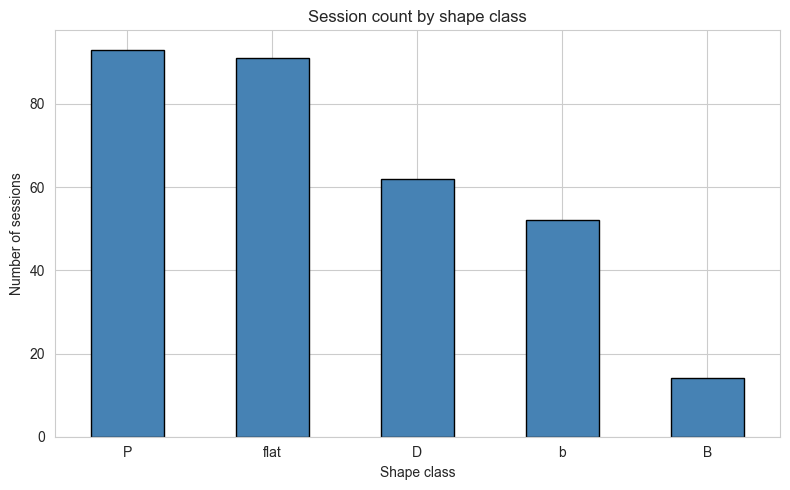

In [129]:
# Count how many sessions fall into each shape class
shape_counts = df['label'].value_counts()
print('Shape counts:')
print(shape_counts.to_string())
print()

# Breakdown of shapes by certainty rating
cert_crosstab = pd.crosstab(df['label'], df['certainty'], margins=True)
print('Shape x Certainty:')
print(cert_crosstab)

# Bar chart of shape counts
fig, ax = plt.subplots(figsize=(8, 5))
shape_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Shape class')
ax.set_ylabel('Number of sessions')
ax.set_title('Session count by shape class')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Drop B-shape and C-certainty

The distribution above shows two issues:

- **B-shape class has only 14 samples** - below what is needed for reliable classification. The B-shape profile is excluded from training.
- **C-certainty labels are marked as "unclear"** - these are unreliable labels that would inject noise into training. They are removed.

After filtering, we keep only sessions labelled D, P, b, or flat with certainty A or B.

In [130]:
# Remember the total size before filtering for the before/after report
n_before = len(df)

# Drop B-shape (too few samples) and C-certainty (unreliable labels)
df = df[df['label'] != 'B'].copy()
df = df[df['certainty'].isin(['A', 'B'])].copy()
df = df.reset_index(drop=True)

print(f'Sessions before filtering:  {n_before}')
print(f'Sessions after filtering:   {len(df)}')
print(f'Dropped:                    {n_before - len(df)}')
print()
print('Final class distribution:')
print(df['label'].value_counts().to_string())
print()
print('Final certainty distribution:')
print(df['certainty'].value_counts().to_string())

Sessions before filtering:  312
Sessions after filtering:   286
Dropped:                    26

Final class distribution:
label
P       90
flat    87
D       59
b       50

Final certainty distribution:
certainty
A    225
B     61


### 3.3 Feature summary statistics by class

Compute per-class mean and standard deviation for each feature. If the features are informative, we expect to see clear differences across classes.

In [131]:
# Group-by-class mean for each feature
per_class_mean = df.groupby('label')[feature_cols].mean().round(4)
print('Per-class mean:')
print(per_class_mean)
print()

# Group-by-class standard deviation for each feature
per_class_std = df.groupby('label')[feature_cols].std().round(4)
print('Per-class std:')
print(per_class_std)

Per-class mean:
       skewness  kurt_excess  poc_position  va_width_ratio  entropy  \
label                                                                 
D        0.0164      -0.2284        0.5151          0.4042   0.9362   
P       -0.7535      -0.1260        0.8020          0.4012   0.9256   
b        0.6525      -0.3780        0.2753          0.4474   0.9393   
flat     0.0248      -0.8375        0.5453          0.5492   0.9555   

       bimodality_coefficient  
label                          
D                      0.4092  
P                      0.5899  
b                      0.5742  
flat                   0.5224  

Per-class std:
       skewness  kurt_excess  poc_position  va_width_ratio  entropy  \
label                                                                 
D        0.3310       0.5593        0.0995          0.0752   0.0202   
P        0.3695       0.8959        0.1037          0.0913   0.0246   
b        0.2139       0.6497        0.1039          0.1019   0.01

### 3.4 Correlation heatmap

Pearson correlation matrix between the six features. `bimodality_coefficient` is mathematically derived from `skewness` and `kurt_excess`, so some correlation here was expected, but this was not confirmed.

Correlation matrix:
                        skewness  kurt_excess  poc_position  va_width_ratio  \
skewness                   1.000       -0.291        -0.752           0.269   
kurt_excess               -0.291        1.000         0.076          -0.822   
poc_position              -0.752        0.076         1.000          -0.081   
va_width_ratio             0.269       -0.822        -0.081           1.000   
entropy                    0.341       -0.731        -0.222           0.739   
bimodality_coefficient    -0.249       -0.168         0.189           0.184   

                        entropy  bimodality_coefficient  
skewness                  0.341                  -0.249  
kurt_excess              -0.731                  -0.168  
poc_position             -0.222                   0.189  
va_width_ratio            0.739                   0.184  
entropy                   1.000                  -0.107  
bimodality_coefficient   -0.107                   1.000  


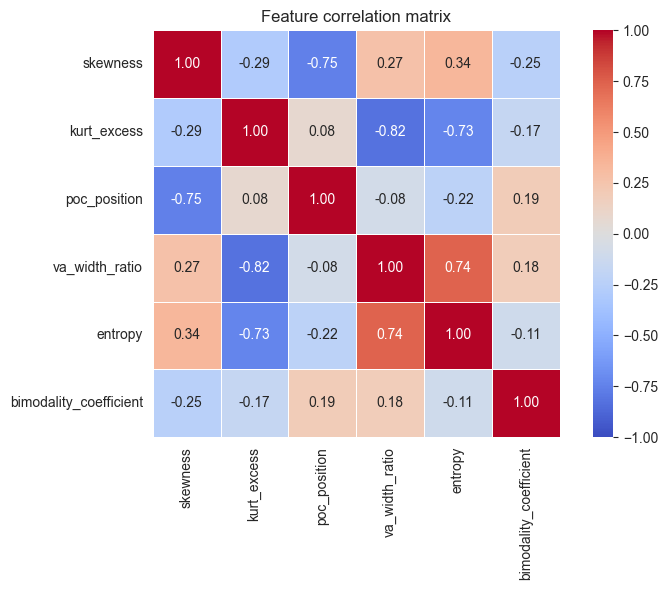

In [132]:
# Pearson correlation matrix between all feature columns
corr_matrix = df[feature_cols].corr()

# Print the full matrix rounded for readability
print('Correlation matrix:')
print(corr_matrix.round(3))

# Heatmap visualisation
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()

### 3.5 Box plots per feature

Box plots summarise each class with its median, interquartile range, and whiskers extending to the typical data range, with outliers plotted as individual points.

C:\Users\uzivatel\AppData\Local\Temp\ipykernel_20484\3206669396.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\uzivatel\AppData\Local\Temp\ipykernel_20484\3206669396.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\uzivatel\AppData\Local\Temp\ipykernel_20484\3206669396.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\uzivatel\AppData\Local\Temp\ipykernel_20484\3206669396.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be 

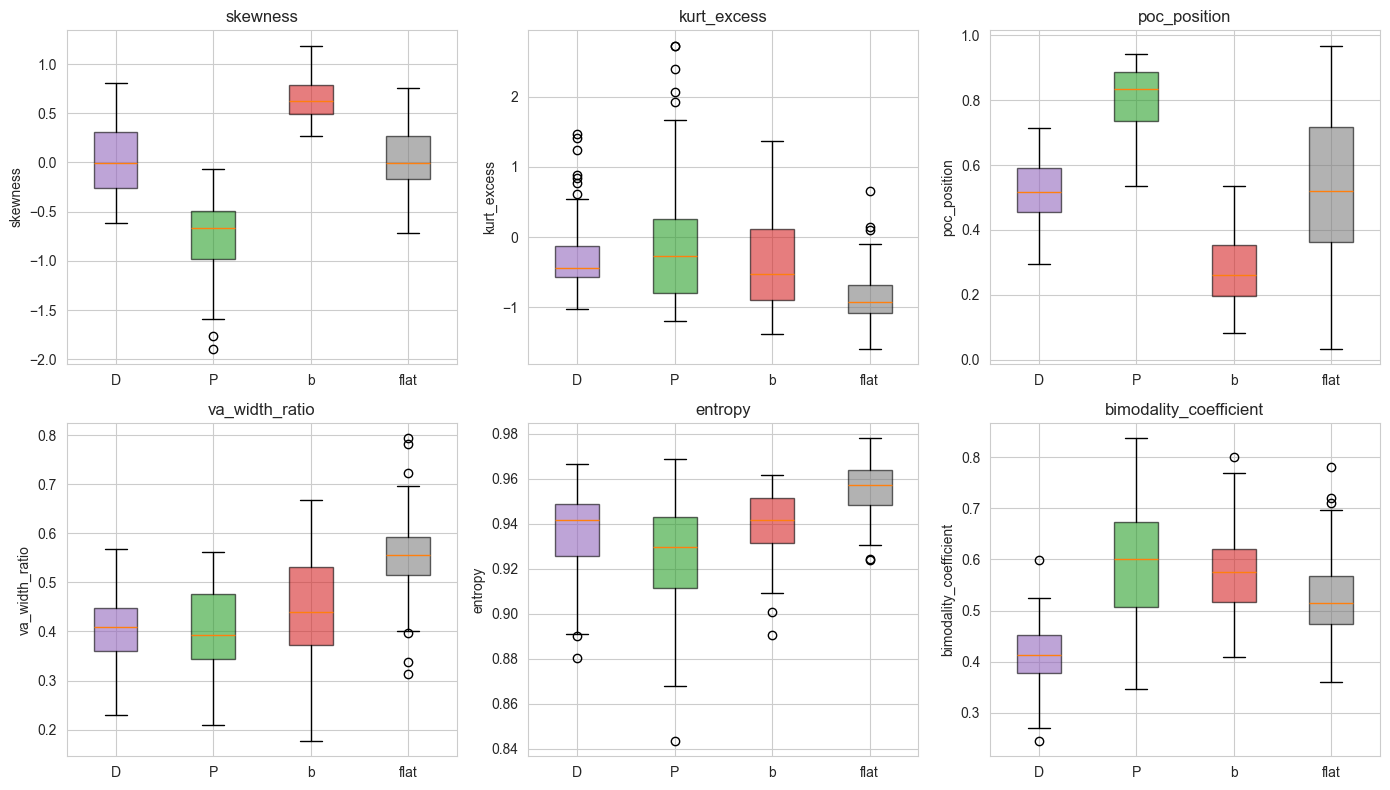

In [133]:
# Fixed colour mapping so the same class always gets the same colour across plots
class_colors = {
    'D': 'tab:purple',
    'P': 'tab:green',
    'b': 'tab:red',
    'flat': 'tab:gray',
}
class_order = ['D', 'P', 'b', 'flat']

# 2x3 grid - one boxplot per feature, grouped by class
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    # Build the data in fixed class order so the x-axis is always the same
    data_per_class = [df[df['label'] == cls][col].values for cls in class_order]
    bp = ax.boxplot(
        data_per_class,
        labels=class_order,
        patch_artist=True,
        showfliers=True,
    )
    # Colour each box to match the class colour map
    for patch, cls in zip(bp['boxes'], class_order):
        patch.set_facecolor(class_colors[cls])
        patch.set_alpha(0.6)
    ax.set_ylabel(col)
    ax.set_title(col)

plt.tight_layout()
plt.show()

### 3.6 Train/test splits for the two experiments

Section 5 will run two independent experiments:

- **Run 1 - A-certainty only:** use only A-certainty samples (textbook-clear labels). Stratified 80/20 split produces `X_train_a` / `X_test_a`.
- **Run 2 - both A+B-certainty:** use both A and B certainty samples (A is clear, B is not textbook but still labelled). Stratified 80/20 split on the larger pool produces `X_train_ab` / `X_test_ab`.

Each run evaluates against its own held-out test set drawn from the same labelling standard as its training data.

I decided to do:

- **Stratified split** (`stratify=y`) so each class is represented proportionally in both train and test, since the classes are imbalanced.
- **Fixed 80/20 ratio** with a reproducible random seed so results are repeatable.

In [134]:
from sklearn.model_selection import train_test_split

# Run 1 dataset: A-certainty samples only
df_a = df[df['certainty'] == 'A'].reset_index(drop=True)
X_a = df_a[feature_cols].values
y_a = df_a['label'].values

# Stratified 80/20 split on A-certainty
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a,
    y_a,
    test_size=0.20,
    stratify=y_a,
    random_state=RANDOM_SEED,
)

# Run 2 dataset: A and B certainty combined
df_ab = df[df['certainty'].isin(['A', 'B'])].reset_index(drop=True)
X_ab = df_ab[feature_cols].values
y_ab = df_ab['label'].values
# Track certainty per row so we can break Run 2 results down by certainty afterwards
cert_ab = df_ab['certainty'].values

# Stratified 80/20 split via indices so features, labels and certainty stay aligned
indices_ab = np.arange(len(df_ab))
train_idx_ab, test_idx_ab = train_test_split(
    indices_ab,
    test_size=0.20,
    stratify=y_ab,
    random_state=RANDOM_SEED,
)
X_train_ab = X_ab[train_idx_ab]
y_train_ab = y_ab[train_idx_ab]
X_test_ab = X_ab[test_idx_ab]
y_test_ab = y_ab[test_idx_ab]
cert_test_ab = cert_ab[test_idx_ab]  # certainty label for each Run 2 test sample

# B-only samples needed for Run 3 test set construction
df_b = df[df['certainty'] == 'B'].reset_index(drop=True)

print('Run 1 (A-only):')
print(f'  Total samples:  {len(df_a)}')
print(f'  Train size:     {len(X_train_a)}')
print(f'  Test size:      {len(X_test_a)}')
print('  Train class counts:')
print('   ', pd.Series(y_train_a).value_counts().to_dict())
print('  Test class counts:')
print('   ', pd.Series(y_test_a).value_counts().to_dict())
print()
print('Run 2 (A+B):')
print(f'  Total samples:  {len(df_ab)}')
print(f'  Train size:     {len(X_train_ab)}')
print(f'  Test size:      {len(X_test_ab)}')
print('  Train class counts:')
print('   ', pd.Series(y_train_ab).value_counts().to_dict())
print('  Test class counts:')
print('   ', pd.Series(y_test_ab).value_counts().to_dict())
print('  Test certainty mix:')
print('   ', pd.Series(cert_test_ab).value_counts().to_dict())

Run 1 (A-only):
  Total samples:  225
  Train size:     180
  Test size:      45
  Train class counts:
    {'P': 66, 'flat': 50, 'D': 34, 'b': 30}
  Test class counts:
    {'P': 16, 'flat': 13, 'D': 9, 'b': 7}

Run 2 (A+B):
  Total samples:  286
  Train size:     228
  Test size:      58
  Train class counts:
    {'P': 72, 'flat': 69, 'D': 47, 'b': 40}
  Test class counts:
    {'P': 18, 'flat': 18, 'D': 12, 'b': 10}
  Test certainty mix:
    {'A': 44, 'B': 14}


## Section 4 - Models

Define the four classifiers and the training infrastructure.

Four classifiers are compared: Random Forest, XGBoost, SVM with RBF kernel, and K-Nearest Neighbours.

### 4.1 Model definitions and hyperparameter grids

Each model is defined with baseline parameters and a small hyperparameter grid for `GridSearchCV`.

| Model | Parameters searched |
| - | - |
| Random Forest | `n_estimators`, `max_depth` |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate` |
| SVM (RBF) | `C`, `gamma` |
| KNN | `n_neighbors`, `weights` |

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs integer-encoded labels rather than strings.
# Fit a shared label encoder on the full set of valid labels so train/test encodings match
label_encoder = LabelEncoder()
label_encoder.fit(class_order)  # uses the class order defined earlier in Section 3
print('Label encoding:')
for cls, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f'  {cls:5s} -> {code}')

# Model definitions with fixed random seeds for reproducibility
rf_model = RandomForestClassifier(random_state=RANDOM_SEED)
rf_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [None, 5, 10],
}

xgb_model = XGBClassifier(
    random_state=RANDOM_SEED,
    eval_metric='mlogloss',
)
xgb_grid = {
    'clf__n_estimators': [100, 200, 300],
    'clf__max_depth': [1, 3, 5, 7],
    'clf__learning_rate': [0.02, 0.05, 0.1],
}

svm_model = SVC(kernel='rbf', random_state=RANDOM_SEED, probability=False)
svm_grid = {
    'clf__C': [0.1, 0.5, 1, 5, 10],
    'clf__gamma': ['scale', 0.1, 1],
}

knn_model = KNeighborsClassifier()
knn_grid = {
    'clf__n_neighbors': [3, 5, 7, 9],
    'clf__weights': ['uniform', 'distance'],
}

# Collect everything so Section 5 can loop over the 4 models cleanly
# Each entry: (name, model instance, grid, needs_scaling, needs_label_encoding)
models_spec = [
    ('Random Forest', rf_model,  rf_grid,  False, False),
    ('XGBoost',       xgb_model, xgb_grid, False, True),
    ('SVM-RBF',       svm_model, svm_grid, True,  False),
    ('KNN',           knn_model, knn_grid, True,  False),
]
print()
print(f'{len(models_spec)} models defined.')

Label encoding:
  D     -> 0
  P     -> 1
  b     -> 2
  flat  -> 3

4 models defined.


### 4.2 Pipeline assembly (scaling + SMOTE)

Two things need to happen consistently during cross-validation:

1. **Feature scaling** for distance-based models (SVM and KNN). Tree ensembles (RF, XGBoost) do not need scaling. Scaling is fit on the training fold only to avoid information leakage from test to train data.
2. **SMOTE resampling** for the imbalanced classes. SMOTE uses k-NN internally, so scaling must happen before SMOTE to ensure all features contribute equally to the neighbour search. Both scaling and SMOTE are applied inside the CV loop, only to the training fold, so synthetic samples never end up in the evaluation set.

In [136]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler


def build_pipeline(model, needs_scaling: bool) -> ImbPipeline:
    # Build pipeline: scaler (if needed) -> SMOTE -> classifier
    # Scaler goes before SMOTE because SMOTE uses k-NN internally  
    # k_neighbors=3 (instead of default 5) because some folds have small class counts
    steps = []
    if needs_scaling:
        steps.append(('scaler', StandardScaler()))
    steps.append(('smote', SMOTE(random_state=RANDOM_SEED, k_neighbors=3)))
    steps.append(('clf', model))
    return ImbPipeline(steps)

### 4.3 Training and evaluation helper

Helper function that trains a model with grid search CV and evaluates it on the test set. Returns a dict with metrics, best params and the fitted model.


Macro F1 is used as the optimisation target because the classes are imbalanced and we want each class weighted equally.

In [137]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
)


def train_and_evaluate(
    name: str,
    model,
    param_grid: dict,
    needs_scaling: bool,
    needs_label_encoding: bool,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
) -> dict:
    """
    Train a model with grid search cross-validation and evaluate on the test set.

    Returns a dict with keys:
      name, best_params, cv_score, test_accuracy, macro_f1, weighted_f1,
      per_class_f1, confusion_matrix, estimator
    """
    # XGBoost needs integer labels; RF/SVM/KNN can work with string labels
    if needs_label_encoding:
        y_train_enc = label_encoder.transform(y_train)
        y_test_enc = label_encoder.transform(y_test)
    else:
        y_train_enc = y_train
        y_test_enc = y_test

    # Assemble pipeline: SMOTE + (scaler if needed) + classifier
    pipeline = build_pipeline(model, needs_scaling)

    # Stratified 5-fold CV 
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    # Grid search optimises macro F1
    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train_enc)

    # Predict on the held-out test set using the best refit estimator
    y_pred_enc = grid.predict(X_test)

    # Decode predictions back to string labels if the model used integer encoding
    if needs_label_encoding:
        y_pred = label_encoder.inverse_transform(y_pred_enc)
        y_test_labels = label_encoder.inverse_transform(y_test_enc)
    else:
        y_pred = y_pred_enc
        y_test_labels = y_test_enc

    # Compute evaluation metrics
    test_acc = accuracy_score(y_test_labels, y_pred)
    macro_f1 = f1_score(y_test_labels, y_pred, average='macro', labels=class_order)
    weighted_f1 = f1_score(y_test_labels, y_pred, average='weighted', labels=class_order)
    per_class_f1 = f1_score(y_test_labels, y_pred, average=None, labels=class_order)
    cm = confusion_matrix(y_test_labels, y_pred, labels=class_order)

    return {
        'name': name,
        'best_params': grid.best_params_,
        'cv_score': grid.best_score_,
        'test_accuracy': test_acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'per_class_f1': dict(zip(class_order, per_class_f1)),
        'confusion_matrix': cm,
        'estimator': grid.best_estimator_,
        'y_test': y_test_labels,
        'y_pred': y_pred,
    }

## Section 5 - Training the Experiments

Two main experiments are compared:

- **Run 1**: train on A-certainty samples only, test on A-certainty samples only.
- **Run 2**: train on A+B samples, test on A+B samples.

Finally, I added also Run 3, which will train on A-certainty samples only and test on A+B samples.

### 5.1 Run 1 - A-only

Train each model on A-certainty samples and evaluate on the A-only test set. 

In [138]:
# Loop over all four models and train each one on the A-only data
results_run1 = []

print('=' * 70)
print('Run 1 - A-only experiment')
print('=' * 70)
print(f'Train size: {len(X_train_a)}  |  Test size: {len(X_test_a)}')
print()

for name, model, grid, needs_scaling, needs_label_enc in models_spec:
    print(f'Training {name}...')
    result = train_and_evaluate(
        name=name,
        model=model,
        param_grid=grid,
        needs_scaling=needs_scaling,
        needs_label_encoding=needs_label_enc,
        X_train=X_train_a,
        y_train=y_train_a,
        X_test=X_test_a,
        y_test=y_test_a,
    )
    results_run1.append(result)

    # One-line progress report per model
    print(f"  CV macro F1:   {result['cv_score']:.4f}")
    print(f"  Test accuracy: {result['test_accuracy']:.4f}")
    print(f"  Test macro F1: {result['macro_f1']:.4f}")
    print(f"  Best params:   {result['best_params']}")
    print()

Run 1 - A-only experiment
Train size: 180  |  Test size: 45

Training Random Forest...
  CV macro F1:   0.8338
  Test accuracy: 0.9556
  Test macro F1: 0.9494
  Best params:   {'clf__max_depth': None, 'clf__n_estimators': 100}

Training XGBoost...
  CV macro F1:   0.8382
  Test accuracy: 0.9111
  Test macro F1: 0.9117
  Best params:   {'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 200}

Training SVM-RBF...
  CV macro F1:   0.8516
  Test accuracy: 0.9333
  Test macro F1: 0.9346
  Best params:   {'clf__C': 1, 'clf__gamma': 0.1}

Training KNN...
  CV macro F1:   0.8251
  Test accuracy: 0.9778
  Test macro F1: 0.9788
  Best params:   {'clf__n_neighbors': 3, 'clf__weights': 'uniform'}



### 5.2 Run 2 - A+B

Same procedure using the larger A+B training pool and the A+B test set.

In [139]:
# Loop over all four models and train each one on the A+B data
results_run2 = []

print('=' * 70)
print('Run 2 - A+B experiment')
print('=' * 70)
print(f'Train size: {len(X_train_ab)}  |  Test size: {len(X_test_ab)}')
print()

for name, model, grid, needs_scaling, needs_label_enc in models_spec:
    print(f'Training {name}...')
    result = train_and_evaluate(
        name=name,
        model=model,
        param_grid=grid,
        needs_scaling=needs_scaling,
        needs_label_encoding=needs_label_enc,
        X_train=X_train_ab,
        y_train=y_train_ab,
        X_test=X_test_ab,
        y_test=y_test_ab,
    )
    results_run2.append(result)

    # One-line progress report per model
    print(f"  CV macro F1:   {result['cv_score']:.4f}")
    print(f"  Test accuracy: {result['test_accuracy']:.4f}")
    print(f"  Test macro F1: {result['macro_f1']:.4f}")
    print(f"  Best params:   {result['best_params']}")
    print()

Run 2 - A+B experiment
Train size: 228  |  Test size: 58

Training Random Forest...
  CV macro F1:   0.8266
  Test accuracy: 0.7931
  Test macro F1: 0.7816
  Best params:   {'clf__max_depth': 5, 'clf__n_estimators': 100}

Training XGBoost...
  CV macro F1:   0.8255
  Test accuracy: 0.7931
  Test macro F1: 0.7775
  Best params:   {'clf__learning_rate': 0.02, 'clf__max_depth': 5, 'clf__n_estimators': 300}

Training SVM-RBF...
  CV macro F1:   0.8412
  Test accuracy: 0.7586
  Test macro F1: 0.7472
  Best params:   {'clf__C': 10, 'clf__gamma': 'scale'}

Training KNN...
  CV macro F1:   0.8305
  Test accuracy: 0.7931
  Test macro F1: 0.7873
  Best params:   {'clf__n_neighbors': 5, 'clf__weights': 'distance'}



### 5.3 Run 3 - Train on A, test on A+B

Reuse the A-only models from Run 1 and evaluate them on a broader test set that includes all B samples (total: 45 A + 61 B = 106 samples). 

In [140]:
def evaluate_on_new_test(existing_result, X_test_new, y_test_new, needs_label_encoding):
    """
    Evaluate an already-trained model from a previous run on a new test set.
    Reuses the fitted estimator and hyperparameters, only recomputes test metrics.
    """
    estimator = existing_result['estimator']

    # Handle XGBoost integer labels (same pattern as train_and_evaluate)
    if needs_label_encoding:
        y_test_enc = label_encoder.transform(y_test_new)
    else:
        y_test_enc = y_test_new

    y_pred_enc = estimator.predict(X_test_new)

    if needs_label_encoding:
        y_pred = label_encoder.inverse_transform(y_pred_enc)
        y_test_labels = label_encoder.inverse_transform(y_test_enc)
    else:
        y_pred = y_pred_enc
        y_test_labels = y_test_enc

    # Compute the same metrics as train_and_evaluate
    test_acc = accuracy_score(y_test_labels, y_pred)
    macro_f1 = f1_score(y_test_labels, y_pred, average='macro', labels=class_order)
    weighted_f1 = f1_score(y_test_labels, y_pred, average='weighted', labels=class_order)
    per_class_f1 = f1_score(y_test_labels, y_pred, average=None, labels=class_order)
    cm = confusion_matrix(y_test_labels, y_pred, labels=class_order)

    return {
        'name': existing_result['name'],
        'best_params': existing_result['best_params'],  # carried over from Run 1
        'cv_score': existing_result['cv_score'],        # carried over from Run 1
        'test_accuracy': test_acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'per_class_f1': dict(zip(class_order, per_class_f1)),
        'confusion_matrix': cm,
        'estimator': estimator,
        'y_test': y_test_labels,
        'y_pred': y_pred,
    }


# Build the Run 3 test set: A held-out samples + all B samples
X_test_r3 = np.vstack([X_test_a, df_b[feature_cols].values])
y_test_r3 = np.concatenate([y_test_a, df_b['label'].values])

print('=' * 70)
print('Run 3 - Train on A, test on A+B')
print('=' * 70)
print(f'Train size: {len(X_train_a)} (same as Run 1)  |  Test size: {len(X_test_r3)}')
print(f'Test composition: {len(X_test_a)} A samples + {len(df_b)} B samples')
print()

# Reuse Run 1's fitted models and evaluate them on the new test set
results_run3 = []
for i, (name, model, grid, needs_scaling, needs_label_enc) in enumerate(models_spec):
    r1_result = results_run1[i]
    print(f'Evaluating {name}...')
    r3_result = evaluate_on_new_test(r1_result, X_test_r3, y_test_r3, needs_label_enc)
    results_run3.append(r3_result)

    print(f"  Test accuracy: {r3_result['test_accuracy']:.4f}")
    print(f"  Test macro F1: {r3_result['macro_f1']:.4f}")
    print()

Run 3 - Train on A, test on A+B
Train size: 180 (same as Run 1)  |  Test size: 106
Test composition: 45 A samples + 61 B samples

Evaluating Random Forest...
  Test accuracy: 0.7170
  Test macro F1: 0.7231

Evaluating XGBoost...
  Test accuracy: 0.6981
  Test macro F1: 0.7076

Evaluating SVM-RBF...
  Test accuracy: 0.7170
  Test macro F1: 0.7237

Evaluating KNN...
  Test accuracy: 0.7453
  Test macro F1: 0.7517



#### Per-certainty breakdown for Run 2 and Run 3

Split each run's test predictions into A and B portions to see which certainty group drives the overall score. Answers whether training on B samples actually helps B-sample classification, and how much it hurts A-sample classification.

In [141]:
# Helper: compute per-certainty accuracy and macro F1 for a masked slice
def split_accuracy(y_true, y_pred, mask):
    if mask.sum() == 0:
        return float('nan'), float('nan')
    acc = accuracy_score(y_true[mask], y_pred[mask])
    f1 = f1_score(y_true[mask], y_pred[mask], average='macro', labels=class_order)
    return acc, f1

# Run 2 masks come from cert_test_ab tracked during the split in Section 3.6
mask_a_r2 = cert_test_ab == 'A'
mask_b_r2 = cert_test_ab == 'B'
n_a_r2 = int(mask_a_r2.sum())
n_b_r2 = int(mask_b_r2.sum())

# Run 3 masks follow the known construction order: X_test_a first, then df_b
n_a_r3 = len(X_test_a)
n_b_r3 = len(df_b)
cert_test_r3 = np.array(['A'] * n_a_r3 + ['B'] * n_b_r3)
mask_a_r3 = cert_test_r3 == 'A'
mask_b_r3 = cert_test_r3 == 'B'

print(f'Run 2 test composition: {n_a_r2} A + {n_b_r2} B = {n_a_r2 + n_b_r2} total')
print(f'Run 3 test composition: {n_a_r3} A + {n_b_r3} B = {n_a_r3 + n_b_r3} total')
print()

# Build the combined breakdown table - one row per model with Run 2 and Run 3 side by side
breakdown_rows = []
for r2, r3 in zip(results_run2, results_run3):
    # Sanity check - the two result lists must share the same model ordering
    assert r2['name'] == r3['name'], 'Model ordering mismatch between runs'

    # Run 2 breakdown: slice predictions by certainty of each test row
    r2_a_acc, _ = split_accuracy(r2['y_test'], r2['y_pred'], mask_a_r2)
    r2_b_acc, _ = split_accuracy(r2['y_test'], r2['y_pred'], mask_b_r2)

    # Run 3 breakdown: slice predictions by fixed certainty layout
    r3_a_acc, _ = split_accuracy(r3['y_test'], r3['y_pred'], mask_a_r3)
    r3_b_acc, _ = split_accuracy(r3['y_test'], r3['y_pred'], mask_b_r3)

    breakdown_rows.append({
        'model': r2['name'],
        'Run 2 A acc': r2_a_acc,
        'Run 2 B acc': r2_b_acc,
        'Run 3 A acc': r3_a_acc,
        'Run 3 B acc': r3_b_acc,
        'A gap (R2 - R3)': r2_a_acc - r3_a_acc,
        'B gap (R2 - R3)': r2_b_acc - r3_b_acc,
    })

breakdown_df = pd.DataFrame(breakdown_rows).round(4)
print('Per-certainty breakdown (Run 2 vs Run 3):')
breakdown_df

Run 2 test composition: 44 A + 14 B = 58 total
Run 3 test composition: 45 A + 61 B = 106 total

Per-certainty breakdown (Run 2 vs Run 3):


,model,Run 2 A acc,Run 2 B acc,Run 3 A acc,Run 3 B acc,A gap (R2 - R3),B gap (R2 - R3)
0,Random Forest,0.8636,0.5714,0.9556,0.5410,-0.0919,0.0304
1,XGBoost,0.8409,0.6429,0.9111,0.5410,-0.0702,0.1019
2,SVM-RBF,0.8409,0.5000,0.9333,0.5574,-0.0924,-0.0574
3,KNN,0.8409,0.6429,0.9778,0.5738,-0.1369,0.0691


#### Reweighted comparison: Run 2 vs Run 3 on matching test composition

Run 2 and Run 3 use different test compositions, so their overall scores are not directly comparable. Reweighting Run 3's per-certainty scores to match Run 2's A/B ratio produces an estimate of Run 3's performance on Run 2's composition, enabling a fairer A-only vs A+B training comparison. I am not reweighting macro F1 score as it is not a linear metric and it would not be mathematically correct.

I am aware that this is still not an apples-to-apples comparison, but I think it is decent for reasonable estimate.

In [142]:
# Target composition = Run 2's test composition
w_a = n_a_r2  # number of A samples in Run 2's test set
w_b = n_b_r2  # number of B samples in Run 2's test set
w_total = w_a + w_b

print(f'Reweighting to Run 2 composition: {w_a} A + {w_b} B = {w_total} total')
print()

reweight_rows = []
for r2, r3 in zip(results_run2, results_run3):
    assert r2['name'] == r3['name'], 'Model ordering mismatch between runs'

    # Run 2 actual overall metrics
    r2_acc = r2['test_accuracy']

    # Run 3 per-certainty metrics from the masks built above
    r3_a_acc, _ = split_accuracy(r3['y_test'], r3['y_pred'], mask_a_r3)
    r3_b_acc, _ = split_accuracy(r3['y_test'], r3['y_pred'], mask_b_r3)

    # Reweight Run 3's per-certainty accuracy to Run 2's composition
    # Accuracy is additive: weighted mean of per-certainty accuracies
    r3_reweighted_acc = (w_a * r3_a_acc + w_b * r3_b_acc) / w_total

    reweight_rows.append({
        'model': r2['name'],
        'Run 2 accuracy': r2_acc,
        'Run 3 accuracy (reweighted)': r3_reweighted_acc,
        'Acc gap (R3 - R2)': r3_reweighted_acc - r2_acc,
    })

reweight_df = pd.DataFrame(reweight_rows).round(4)
print('Run 3 (A-only training) reweighted to Run 2 composition vs Run 2 (A+B training):')
reweight_df

Reweighting to Run 2 composition: 44 A + 14 B = 58 total

Run 3 (A-only training) reweighted to Run 2 composition vs Run 2 (A+B training):


,model,Run 2 accuracy,Run 3 accuracy (reweighted),Acc gap (R3 - R2)
0,Random Forest,0.7931,0.8555,0.0624
1,XGBoost,0.7931,0.8218,0.0287
2,SVM-RBF,0.7586,0.8426,0.0840
3,KNN,0.7931,0.8803,0.0872


### 5.4 Combined comparison table

All three runs side by side: CV macro F1, test accuracy, macro F1, weighted F1. Sorted by experiment then macro F1 descending so the best model in each run is at the top of its group.

In [143]:
# Helper to turn a list of result dicts into a tidy DataFrame
def results_to_dataframe(results: list, experiment_name: str) -> pd.DataFrame:
    rows = []
    for r in results:
        rows.append({
            'experiment': experiment_name,
            'model': r['name'],
            'cv_macro_f1': r['cv_score'],
            'test_accuracy': r['test_accuracy'],
            'test_macro_f1': r['macro_f1'],
            'test_weighted_f1': r['weighted_f1'],
        })
    return pd.DataFrame(rows)

# Build and concatenate the three experiment DataFrames
df_run1 = results_to_dataframe(results_run1, 'Run 1: A -> A')
df_run2 = results_to_dataframe(results_run2, 'Run 2: A+B -> A+B')
df_run3 = results_to_dataframe(results_run3, 'Run 3: A -> A+B')
comparison = pd.concat([df_run1, df_run2, df_run3], ignore_index=True)

# Sort by experiment (preserving run order) then by macro F1 descending
comparison = comparison.sort_values(
    ['experiment', 'test_macro_f1'],
    ascending=[True, False],
).reset_index(drop=True)

print('Combined comparison (sorted by test macro F1 within each experiment):')
comparison.round(4)

Combined comparison (sorted by test macro F1 within each experiment):


,experiment,model,cv_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1
0,Run 1: A -> A,KNN,0.8251,0.9778,0.9788,0.9780
1,Run 1: A -> A,Random Forest,0.8338,0.9556,0.9494,0.9556
2,Run 1: A -> A,SVM-RBF,0.8516,0.9333,0.9346,0.9340
3,Run 1: A -> A,XGBoost,0.8382,0.9111,0.9117,0.9113
4,Run 2: A+B -> A+B,KNN,0.8305,0.7931,0.7873,0.7881
5,Run 2: A+B -> A+B,Random Forest,0.8266,0.7931,0.7816,0.7795
6,Run 2: A+B -> A+B,XGBoost,0.8255,0.7931,0.7775,0.7806
7,Run 2: A+B -> A+B,SVM-RBF,0.8412,0.7586,0.7472,0.7497
8,Run 3: A -> A+B,KNN,0.8251,0.7453,0.7517,0.7402
9,Run 3: A -> A+B,SVM-RBF,0.8516,0.7170,0.7237,0.7152


## Section 6 - Results Visualisation and Analysis

Visualise the Section 5 results. 

### 6.1 F1 score breakdown

Per-class F1 bars (one panel per run) to show class-level performance, plus a macro F1 summary chart across all runs and models.

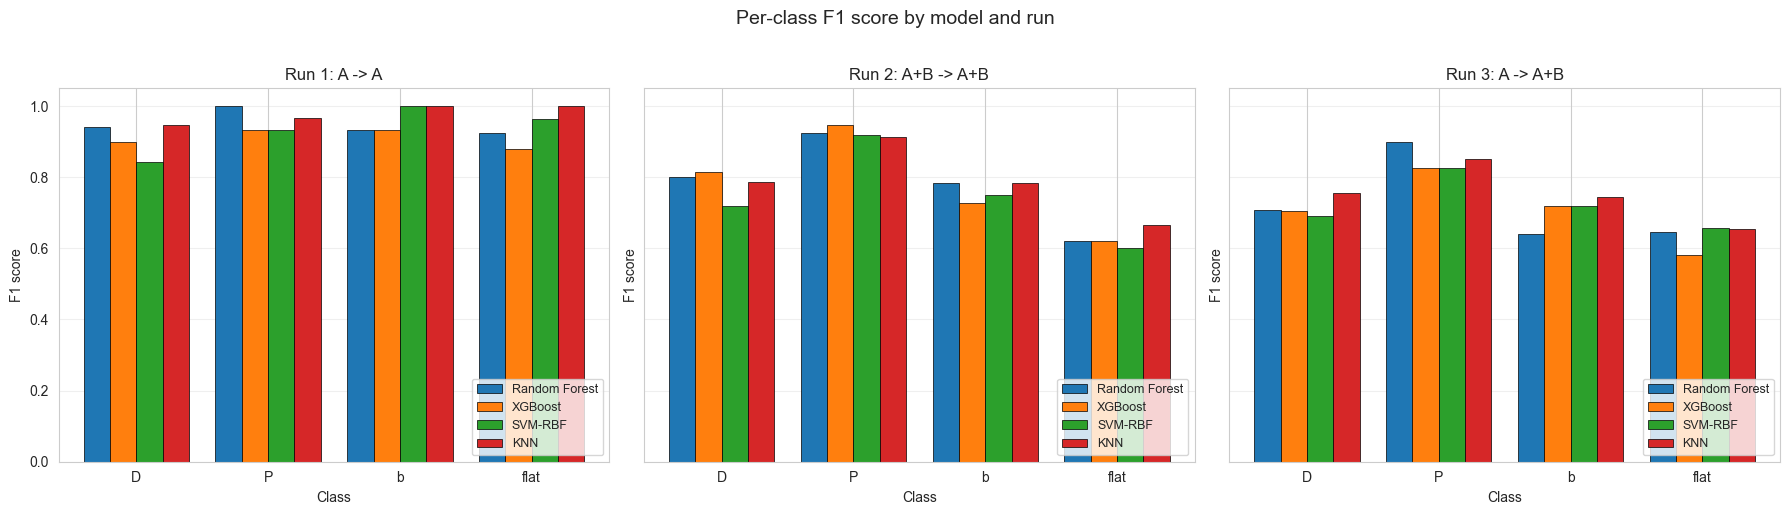

In [144]:
def plot_per_class_f1(results_list, title: str, ax):
    """
    Grouped bar chart of per-class F1 scores. X-axis is class, and each
    class group contains one bar per model in the results list.
    """
    n_classes = len(class_order)
    n_models = len(results_list)
    bar_width = 0.8 / n_models
    x_positions = np.arange(n_classes)

    # Distinct colour per model for this grouped bar plot
    model_palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for m_idx, result in enumerate(results_list):
        f1_values = [result['per_class_f1'][cls] for cls in class_order]
        offset = (m_idx - n_models / 2 + 0.5) * bar_width
        ax.bar(
            x_positions + offset,
            f1_values,
            bar_width,
            label=result['name'],
            color=model_palette[m_idx],
            edgecolor='black',
            linewidth=0.5,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(class_order)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F1 score')
    ax.set_xlabel('Class')
    ax.set_title(title)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.3)


# Three subplots side-by-side, one per run
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_per_class_f1(results_run1, 'Run 1: A -> A', axes[0])
plot_per_class_f1(results_run2, 'Run 2: A+B -> A+B', axes[1])
plot_per_class_f1(results_run3, 'Run 3: A -> A+B', axes[2])
plt.suptitle('Per-class F1 score by model and run', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

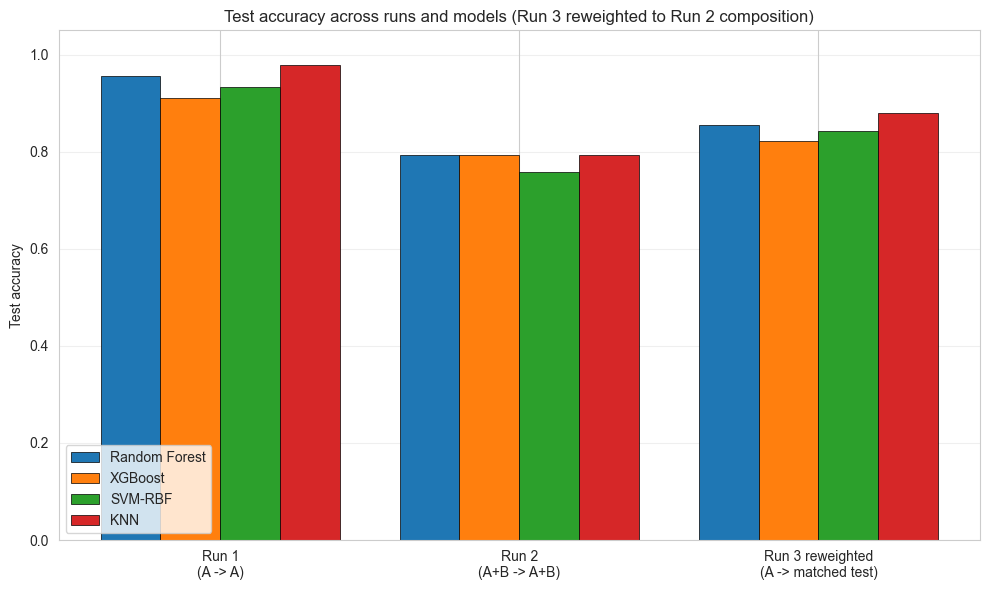

In [145]:
# Compute Run 3 reweighted accuracy so it can be compared with Run 2.
# Run 3 actual scores are biased low because B samples dominate its test set.
# Reweighting to Run 2's composition removes that bias.
# Note: only accuracy is reweighted (macro F1 is non-linear and cannot be
# validly reweighted as a simple weighted average).
w_total = n_a_r2 + n_b_r2

run3_reweighted_acc = []
for r3 in results_run3:
    r3_a_acc, _ = split_accuracy(r3['y_test'], r3['y_pred'], mask_a_r3)
    r3_b_acc, _ = split_accuracy(r3['y_test'], r3['y_pred'], mask_b_r3)
    rw = (n_a_r2 * r3_a_acc + n_b_r2 * r3_b_acc) / w_total
    run3_reweighted_acc.append(rw)

# Per-run accuracy values: Run 1 and Run 2 use their native test sets,
# Run 3 uses the reweighted estimate so all three are on the same composition baseline
run_labels = [
    'Run 1\n(A -> A)',
    'Run 2\n(A+B -> A+B)',
    'Run 3 reweighted\n(A -> matched test)',
]
model_names = [r['name'] for r in results_run1]
n_runs = len(run_labels)
n_models = len(model_names)

acc_matrix = np.zeros((n_runs, n_models))
for m_idx in range(n_models):
    acc_matrix[0, m_idx] = results_run1[m_idx]['test_accuracy']     # native
    acc_matrix[1, m_idx] = results_run2[m_idx]['test_accuracy']     # native
    acc_matrix[2, m_idx] = run3_reweighted_acc[m_idx]               # reweighted

# Grouped bar chart: one group per run, one bar per model within each group
model_palette = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
bar_width = 0.8 / n_models
x_positions = np.arange(n_runs)

fig, ax = plt.subplots(figsize=(10, 6))
for m_idx, name in enumerate(model_names):
    offset = (m_idx - n_models / 2 + 0.5) * bar_width
    ax.bar(
        x_positions + offset,
        acc_matrix[:, m_idx],
        bar_width,
        label=name,
        color=model_palette[m_idx],
        edgecolor='black',
        linewidth=0.5,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(run_labels)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Test accuracy')
ax.set_title('Test accuracy across runs and models (Run 3 reweighted to Run 2 composition)')
ax.legend(loc='lower left', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Confusion matrices

Raw-count confusion matrices for every model in every run. Rows are true class, columns are predicted class, diagonal is correct.

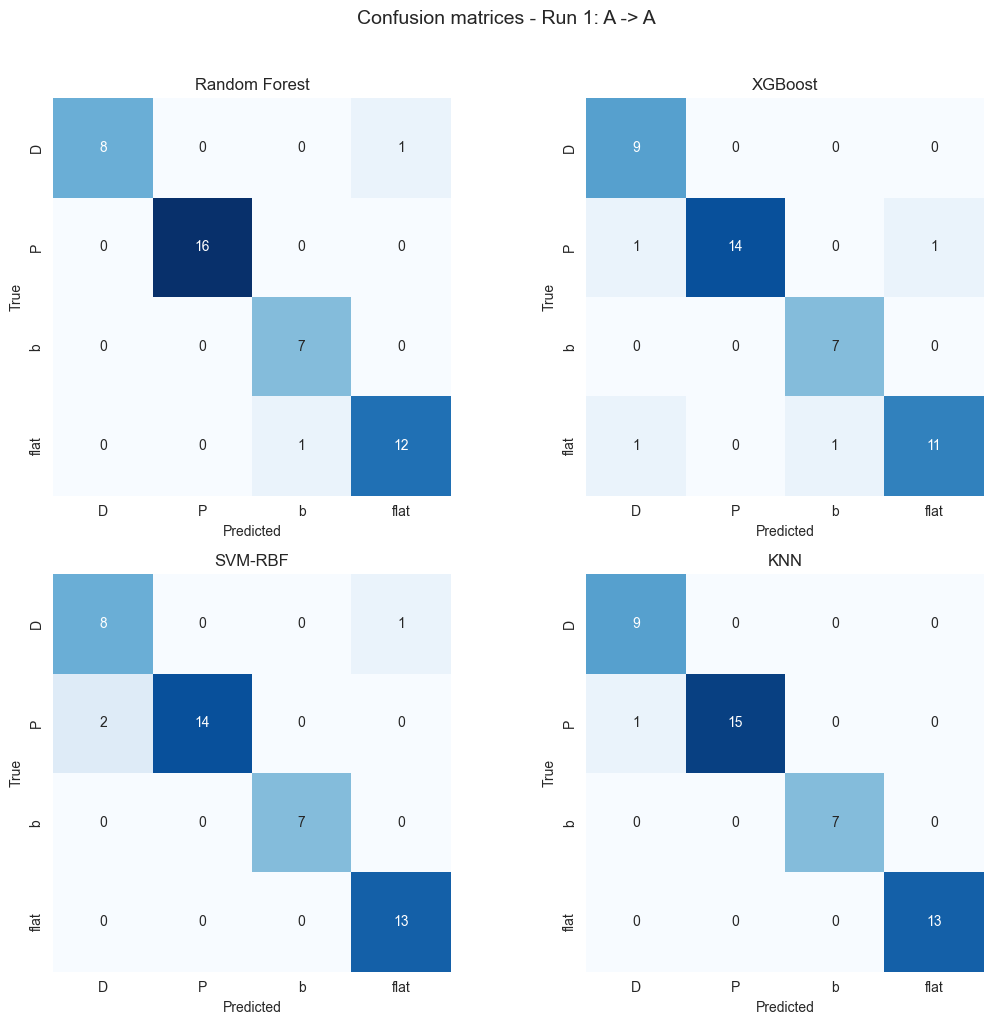

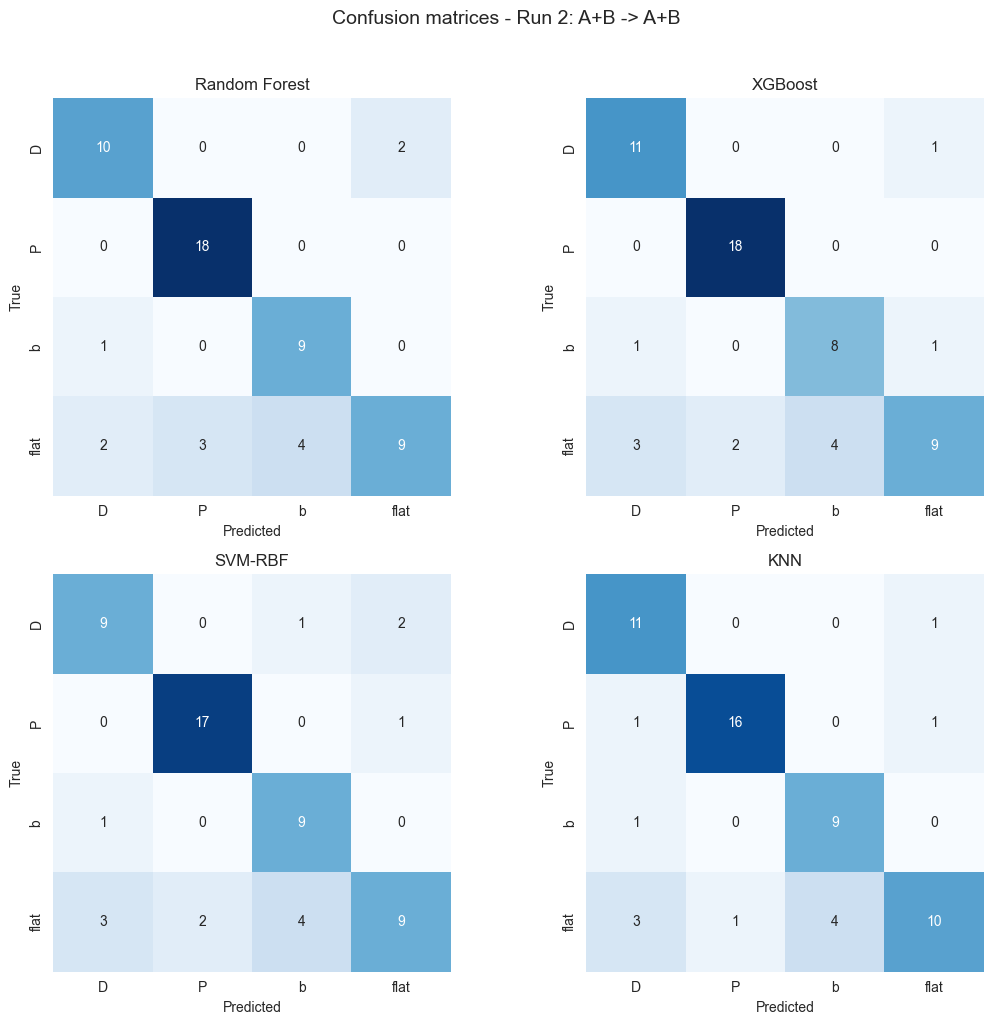

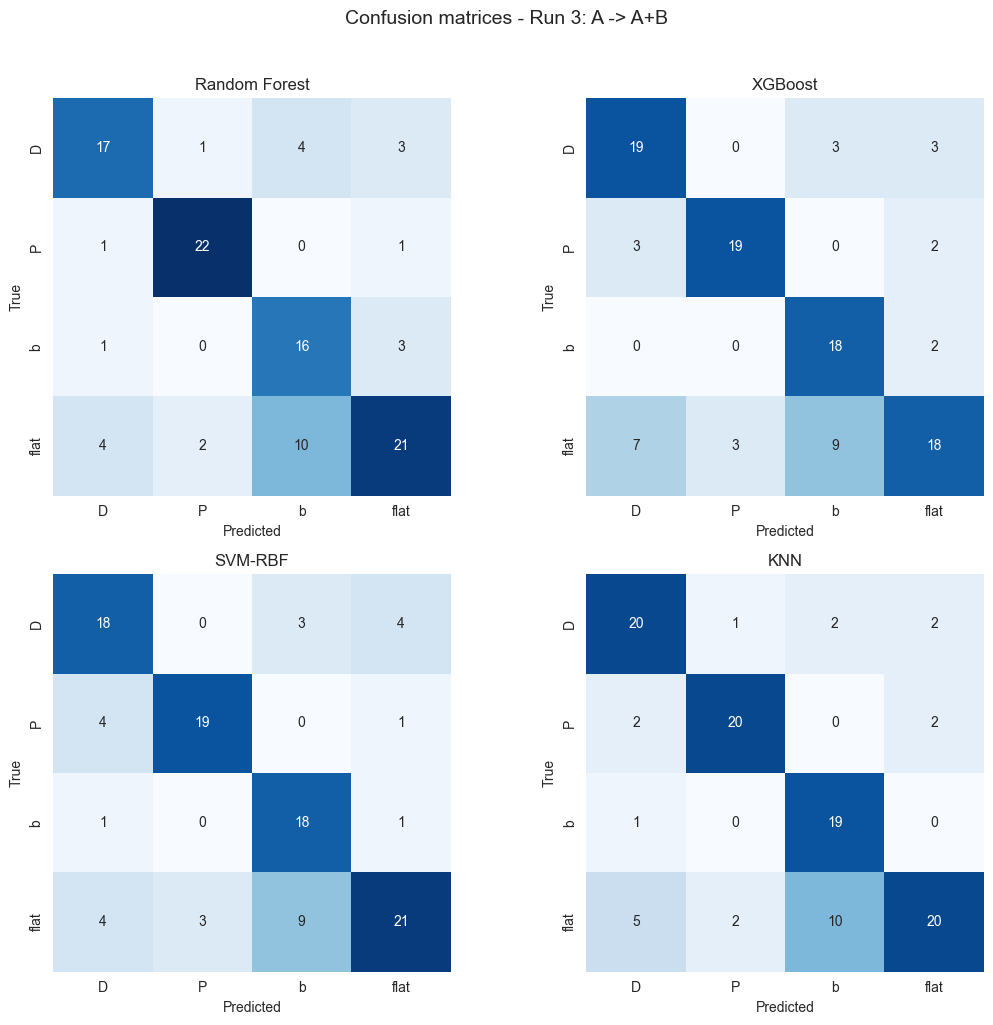

In [146]:
def plot_confusion_matrices(results_list, run_title: str):
    """
    Plot a 2x2 grid of confusion matrices, one per model in the results list.
    Uses raw counts and a consistent colour scale across the grid.
    """
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    axes = axes.flatten()

    # Use a shared colour scale across all 4 matrices in this run
    vmax = max(r['confusion_matrix'].max() for r in results_list)

    for idx, result in enumerate(results_list):
        ax = axes[idx]
        cm = result['confusion_matrix']
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            vmin=0,
            vmax=vmax,
            xticklabels=class_order,
            yticklabels=class_order,
            cbar=False,
            square=True,
            ax=ax,
        )
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title(result['name'])

    fig.suptitle(f'Confusion matrices - {run_title}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_confusion_matrices(results_run1, 'Run 1: A -> A')
plot_confusion_matrices(results_run2, 'Run 2: A+B -> A+B')
plot_confusion_matrices(results_run3, 'Run 3: A -> A+B')

### 6.3 Feature importance

Random Forest and XGBoost feature importance for Run 1 and Run 2. SVM and KNN are skipped because they do not expose built-in feature importances. Run 3 is skipped because it reuses Run 1's estimators unchanged.

Run 1 - Random Forest feature importance (trained on A-only):
               feature  importance
              skewness      0.3180
          poc_position      0.2408
bimodality_coefficient      0.1478
        va_width_ratio      0.1435
               entropy      0.0791
           kurt_excess      0.0708

Run 2 - Random Forest feature importance (trained on A+B):
               feature  importance
              skewness      0.3303
          poc_position      0.2241
bimodality_coefficient      0.1544
        va_width_ratio      0.1479
           kurt_excess      0.0844
               entropy      0.0588


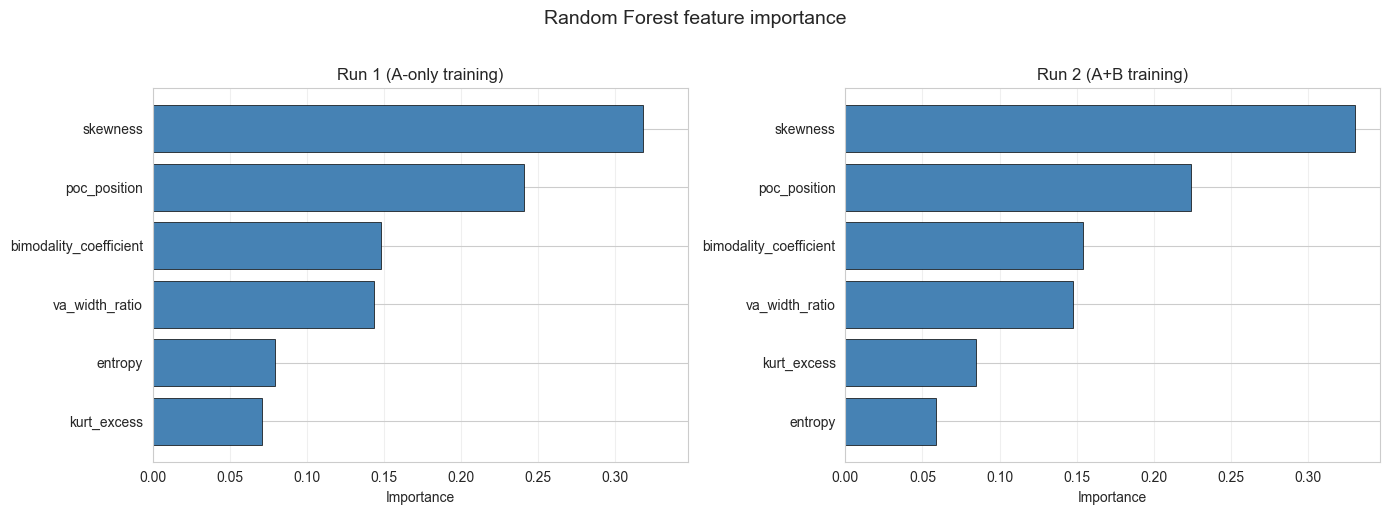

Run 1 - XGBoost feature importance (trained on A-only):
               feature  importance
              skewness      0.3345
bimodality_coefficient      0.2227
        va_width_ratio      0.1736
          poc_position      0.1712
           kurt_excess      0.0563
               entropy      0.0418

Run 2 - XGBoost feature importance (trained on A+B):
               feature  importance
              skewness      0.3886
bimodality_coefficient      0.2247
        va_width_ratio      0.1565
          poc_position      0.1049
               entropy      0.0647
           kurt_excess      0.0606


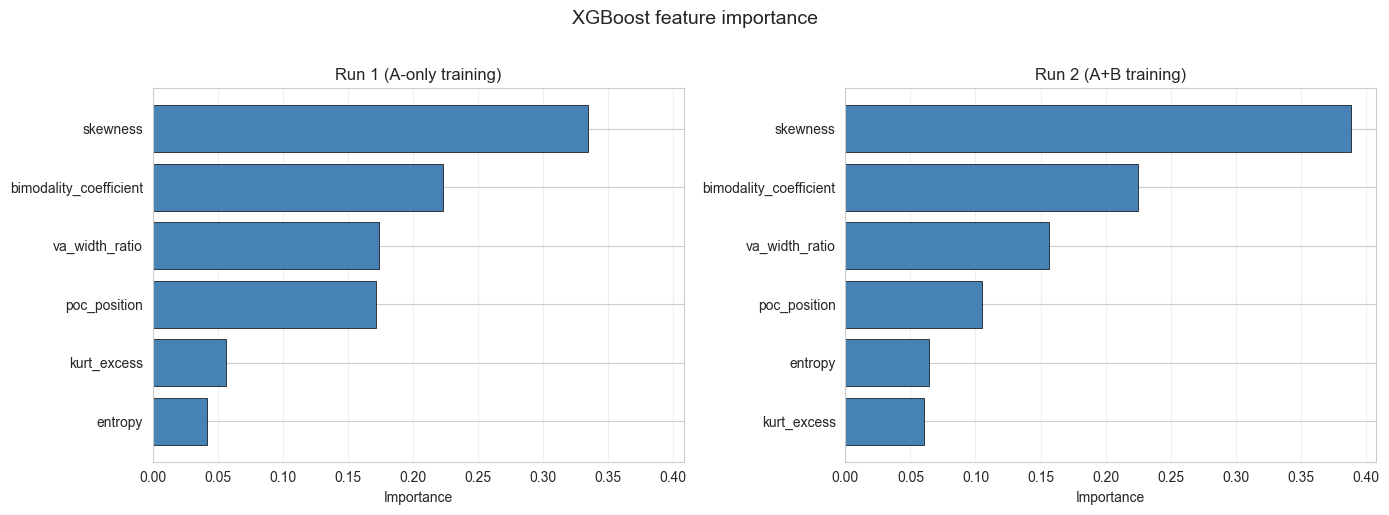

In [147]:
def get_importances(results_list, model_name: str) -> pd.DataFrame:
    """Extract feature importances from a model's fitted pipeline in a given run."""
    result = next(r for r in results_list if r['name'] == model_name)
    clf = result['estimator'].named_steps['clf']
    return pd.DataFrame({
        'feature': feature_cols,
        'importance': clf.feature_importances_,
    }).sort_values('importance', ascending=True)


def plot_importance_run1_vs_run2(model_name: str):
    """Side-by-side horizontal bar charts of Run 1 vs Run 2 importance for one model."""
    imp_run1 = get_importances(results_run1, model_name)
    imp_run2 = get_importances(results_run2, model_name)

    print(f'Run 1 - {model_name} feature importance (trained on A-only):')
    print(imp_run1.iloc[::-1].round(4).to_string(index=False))
    print()
    print(f'Run 2 - {model_name} feature importance (trained on A+B):')
    print(imp_run2.iloc[::-1].round(4).to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
    for ax, imp_df, title in zip(
        axes,
        [imp_run1, imp_run2],
        ['Run 1 (A-only training)', 'Run 2 (A+B training)'],
    ):
        ax.barh(
            imp_df['feature'],
            imp_df['importance'],
            color='steelblue',
            edgecolor='black',
            linewidth=0.5,
        )
        ax.set_xlabel('Importance')
        ax.set_title(title)
        ax.grid(axis='x', alpha=0.3)

    plt.suptitle(f'{model_name} feature importance', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# Random Forest feature importance
plot_importance_run1_vs_run2('Random Forest')

# XGBoost feature importance
plot_importance_run1_vs_run2('XGBoost')